In [120]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [121]:
df = pd.read_csv('orbit_data.csv')
print(df.head())

   Time            X1            Y1         X2       Y2        Energy
0     0  1.362100e-21  0.000000e+00  6999990.0   7500.0 -2.881630e+10
1     1  4.086310e-21  1.459400e-24  6999980.0  15000.0 -2.881630e+10
2     2  8.172610e-21  5.837590e-24  6999950.0  22500.0 -2.881630e+10
3     3  1.362100e-20  1.459400e-23  6999920.0  29999.9 -2.881630e+10
4     4  2.043150e-20  2.918800e-23  6999880.0  37499.8 -2.881630e+10


In [122]:
print(df.describe())

              Time            X1            Y1            X2            Y2  \
count  10000.00000  1.000000e+04  1.000000e+04  1.000000e+04  1.000000e+04   
mean    4999.50000  1.256680e-15  6.174202e-15 -5.048925e+05  6.314133e+05   
std     2886.89568  8.129671e-16  3.917629e-15  4.855039e+06  4.848834e+06   
min        0.00000 -2.874310e-23  0.000000e+00 -6.832070e+06 -6.919230e+06   
25%     2499.75000  4.432585e-16  2.690570e-15 -5.232450e+06 -4.206250e+06   
50%     4999.50000  1.373110e-15  7.099005e-15 -1.200205e+06  1.357800e+06   
75%     7499.25000  2.048300e-15  8.339788e-15  4.352858e+06  5.344818e+06   
max     9999.00000  2.316150e-15  1.371720e-14  7.000000e+06  6.911820e+06   

             Energy  
count  1.000000e+04  
mean  -2.881633e+10  
std    2.790200e+05  
min   -2.881670e+10  
25%   -2.881660e+10  
50%   -2.881640e+10  
75%   -2.881610e+10  
max   -2.881590e+10  


In [123]:
print(df.isnull().sum())

Time      0
X1        0
Y1        0
X2        0
Y2        0
Energy    0
dtype: int64


In [124]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    10000 non-null  int64  
 1   X1      10000 non-null  float64
 2   Y1      10000 non-null  float64
 3   X2      10000 non-null  float64
 4   Y2      10000 non-null  float64
 5   Energy  10000 non-null  float64
dtypes: float64(5), int64(1)
memory usage: 468.9 KB
None


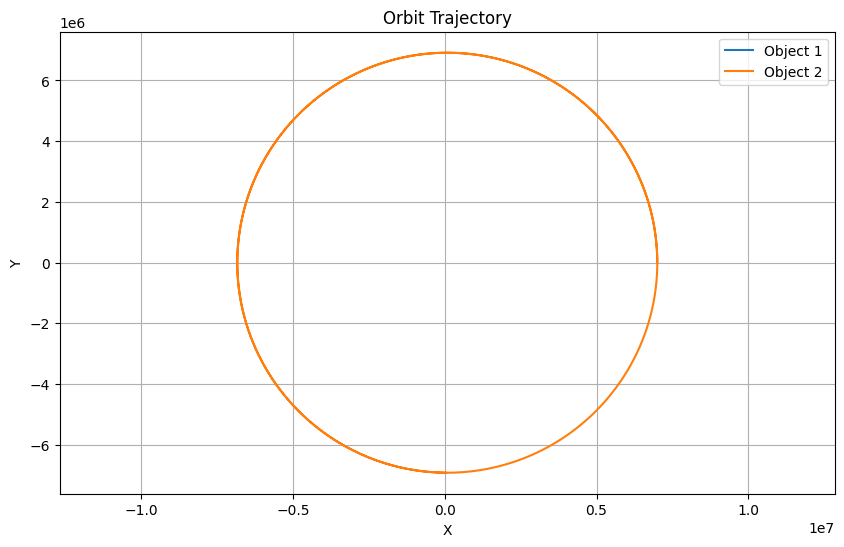

In [125]:
plt.figure(figsize=(10, 6))
plt.plot(df["X1"], df["Y1"], label="Object 1")
plt.plot(df["X2"], df["Y2"], label="Object 2")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.title("Orbit Trajectory")
plt.axis("equal")
plt.grid()
plt.show()

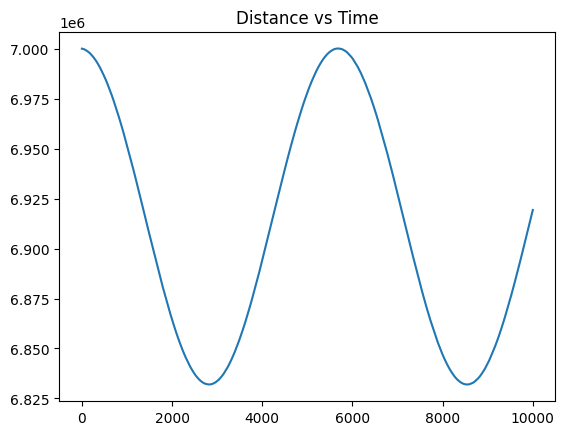

In [126]:
df["distance"] = np.sqrt(
    (df["X2"] - df["X1"])**2 +
    (df["Y2"] - df["Y1"])**2
)
plt.plot(df["Time"], df["distance"])
plt.title("Distance vs Time")
plt.show()

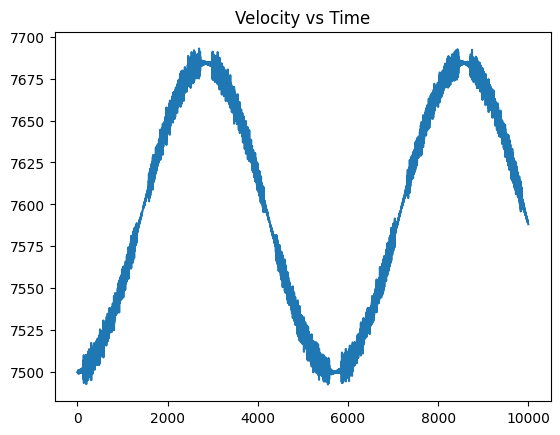

In [127]:
dt = 1
df["vx2"] = df["X2"].diff() / dt
df["vy2"] = df["Y2"].diff() / dt
df["speed2"] = np.sqrt(df["vx2"]**2 + df["vy2"]**2)
plt.plot(df["Time"], df["speed2"])
plt.title("Velocity vs Time")
plt.show()

In [128]:
avg_dist = df["distance"].mean()
std_dist = df["distance"].std()
if std_dist < 0.01 * avg_dist:
    print("Circular Orbit")
elif std_dist < 0.5 * avg_dist:
    print("Elliptical Orbit")
else:
    print("Unstable Orbit")

Circular Orbit
